In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [5]:
# Load dataset Titanic
df = sns.load_dataset('titanic')

# Lihat 5 baris pertama
print(df.head())

# Info dataset
print(f"\nJumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Jumlah baris: 891
Jumlah kolom: 15


Data yang hilang:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


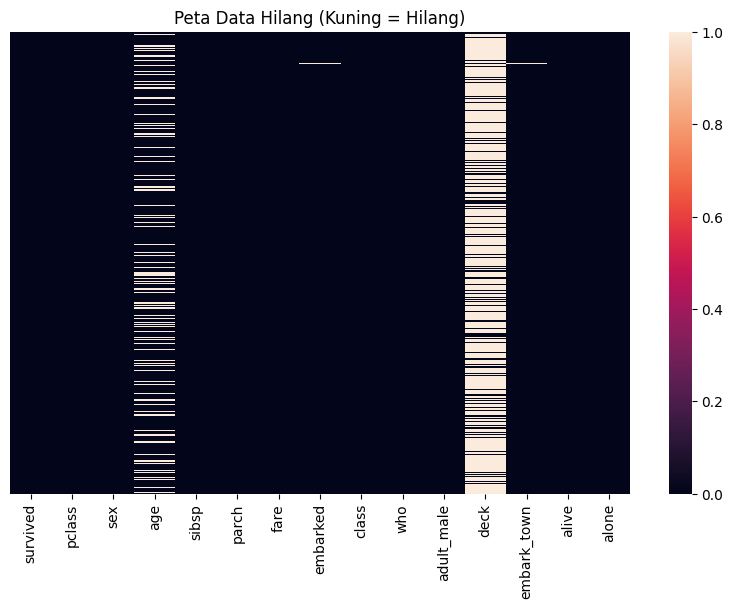

In [6]:
# Cek data kosong
print("Data yang hilang:")
print(df.isnull().sum())

# Visualisasi dengan heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False)
plt.title('Peta Data Hilang (Kuning = Hilang)')
plt.show()

In [13]:
# Cara 1: Isi dengan nilai tengah (median)
df['age'].fillna(df['age'].median(), inplace=True)

# Cara 2: Isi dengan nilai paling sering (mode)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Cara 3: Hapus baris yang masih kosong
df = df.dropna()

print("Data hilang setelah dibersihkan:", df.isnull().sum().sum())

Data hilang setelah dibersihkan: 0


C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_16260\3230950160.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_16260\3230950160.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained as

In [8]:
# Cek dan hapus duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Jumlah data sekarang: {len(df)}")

Jumlah duplikat: 1
Jumlah data sekarang: 181


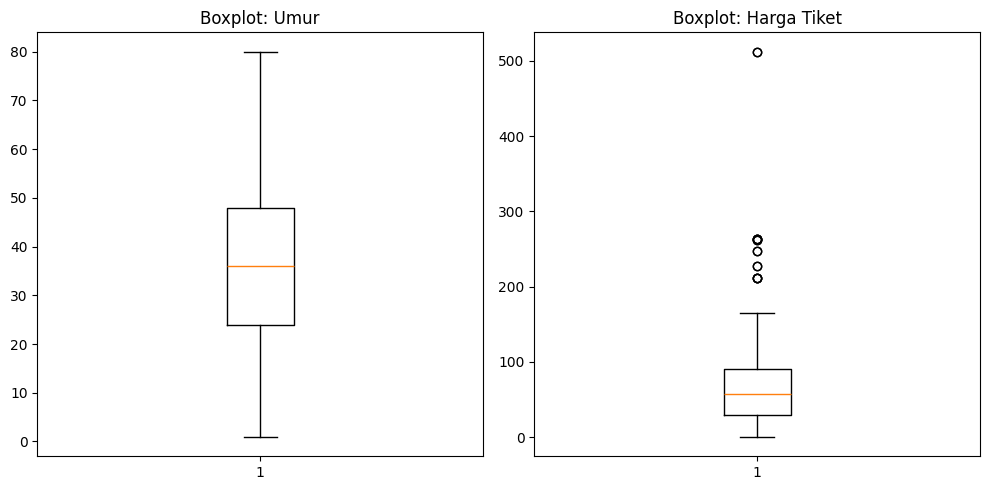

Harga maksimal setelah capping: 180.45


In [9]:
# Lihat outliers pakai boxplot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df['age'].dropna())
plt.title('Boxplot: Umur')

plt.subplot(1, 2, 2)
plt.boxplot(df['fare'].dropna())
plt.title('Boxplot: Harga Tiket')

plt.tight_layout()
plt.show()

# Batasi outliers (capping)
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

df['fare'] = df['fare'].clip(upper=upper_limit)
print(f"Harga maksimal setelah capping: {df['fare'].max()}")

In [10]:
# Pilih kolom angka
data_angka = df[['age', 'fare']].copy()

# Normalisasi ke skala 0-1
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_angka)
df_norm = pd.DataFrame(data_normalized, columns=['age', 'fare'])

# Bandingkan
print("SEBELUM Normalisasi:")
print(data_angka.head())
print("\nSESUDAH Normalisasi:")
print(df_norm.head())

SEBELUM Normalisasi:
     age     fare
1   38.0  71.2833
3   35.0  53.1000
6   54.0  51.8625
10   4.0  16.7000
11  58.0  26.5500

SESUDAH Normalisasi:
        age      fare
0  0.468892  0.395031
1  0.430956  0.294264
2  0.671219  0.287406
3  0.038948  0.092546
4  0.721801  0.147132


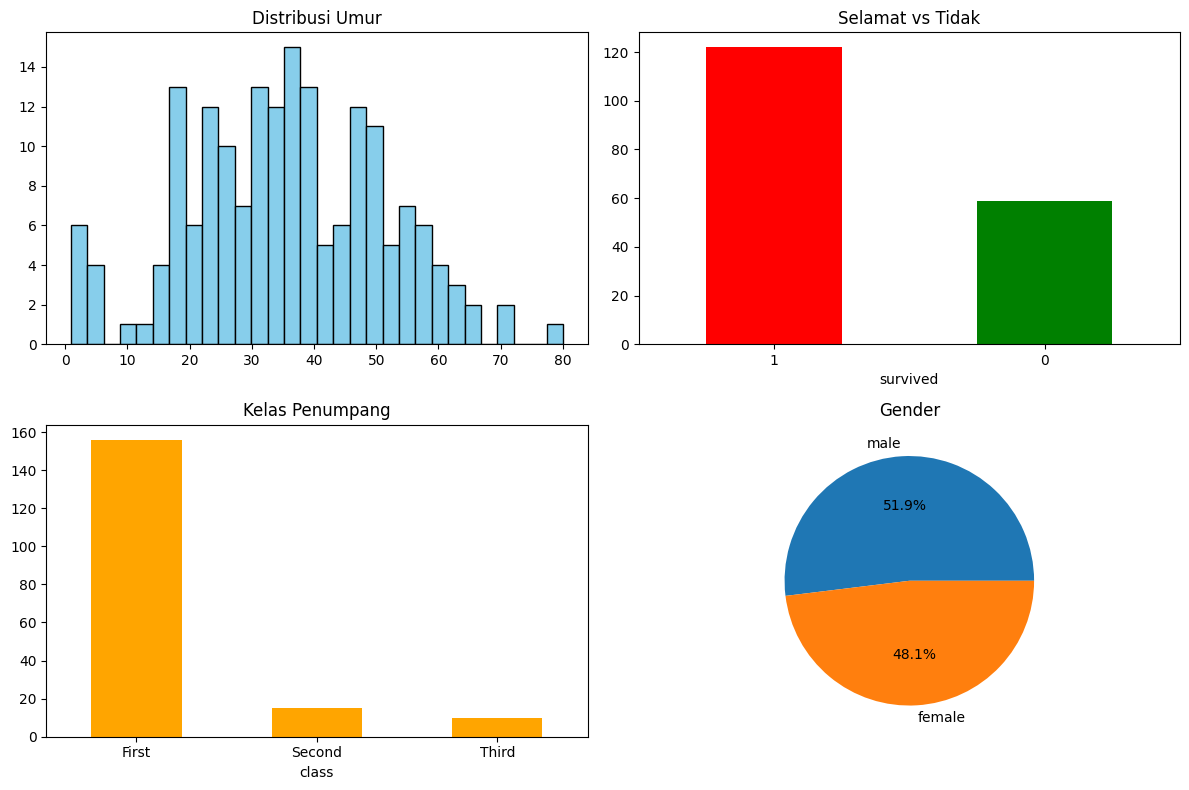

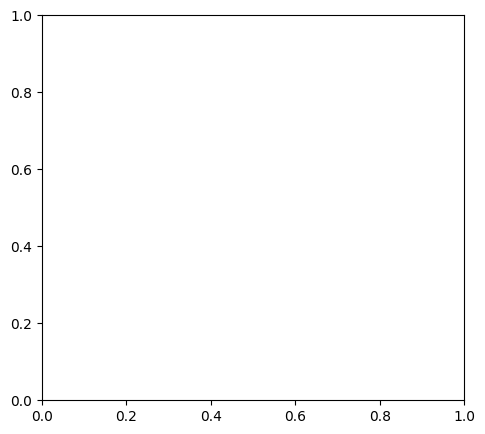

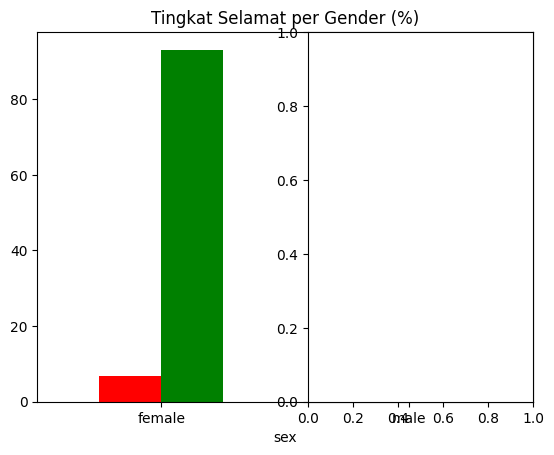

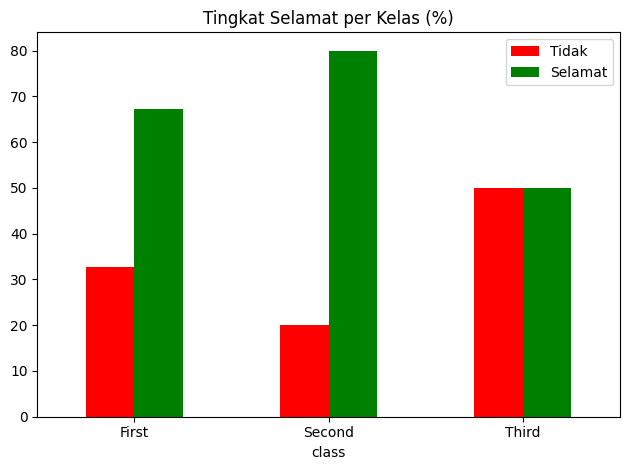

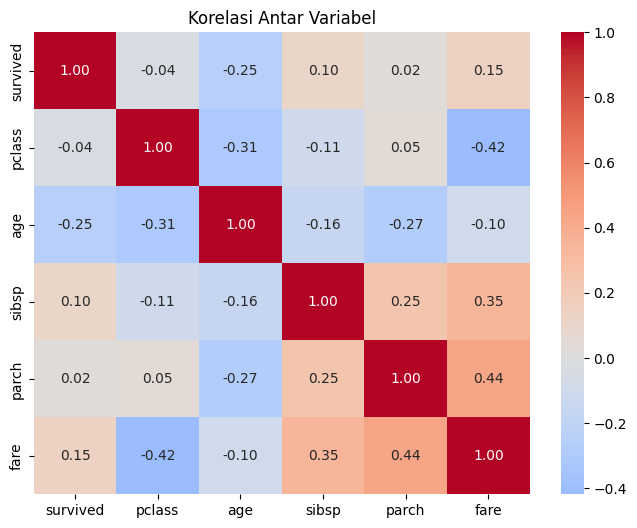

In [11]:
# 1. Lihat distribusi data
plt.figure(figsize=(12, 8))

# Umur penumpang
plt.subplot(2, 2, 1)
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Umur')

# Selamat atau tidak
plt.subplot(2, 2, 2)
df['survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Selamat vs Tidak')
plt.xticks(rotation=0)

# Kelas penumpang
plt.subplot(2, 2, 3)
df['class'].value_counts().plot(kind='bar', color='orange')
plt.title('Kelas Penumpang')
plt.xticks(rotation=0)

# Gender
plt.subplot(2, 2, 4)
df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender')

plt.tight_layout()
plt.show()

# 2. Analisis hubungan antar variabel
plt.figure(figsize=(12, 5))

# Tingkat selamat berdasarkan gender
plt.subplot(1, 2, 1)
survival_gender = pd.crosstab(df['sex'], df['survived'], normalize='index') * 100
survival_gender.plot(kind='bar', color=['red', 'green'])
plt.title('Tingkat Selamat per Gender (%)')
plt.legend(['Tidak', 'Selamat'])
plt.xticks(rotation=0)

# Tingkat selamat berdasarkan kelas
plt.subplot(1, 2, 2)
survival_class = pd.crosstab(df['class'], df['survived'], normalize='index') * 100
survival_class.plot(kind='bar', color=['red', 'green'])
plt.title('Tingkat Selamat per Kelas (%)')
plt.legend(['Tidak', 'Selamat'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 3. Correlation Matrix
kolom_angka = df.select_dtypes(include=[np.number])
korelasi = kolom_angka.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.show()

In [ ]:
#TUGAS 1
df = sns.load_dataset('tips')

print("--- 1. Jumlah Data Hilang per Kolom ---")
missing_data = df.isnull().sum()
print(missing_data)
print("-" * 35)

df_cleaned = df.dropna()
print(f"--- 2. Data hilang telah ditangani (Metode: Dropna) ---")

jumlah_duplikat = df_cleaned.duplicated().sum()
print(f"--- 3. Jumlah data duplikat ditemukan: {jumlah_duplikat} ---")

df_final = df_cleaned.drop_duplicates()
print("Duplikat telah dihapus.")
print("-" * 35)

print("--- 4. Hasil Akhir (5 baris pertama) ---")
print(df_final.head())
print(f"\nUkuran akhir dataset: {df_final.shape}")

--- 1. Jumlah Data Hilang per Kolom ---
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
-----------------------------------
--- 2. Data hilang telah ditangani (Metode: Dropna) ---
--- 3. Jumlah data duplikat ditemukan: 1 ---
Duplikat telah dihapus.
-----------------------------------
--- 4. Hasil Akhir (5 baris pertama) ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Ukuran akhir dataset: (243, 7)


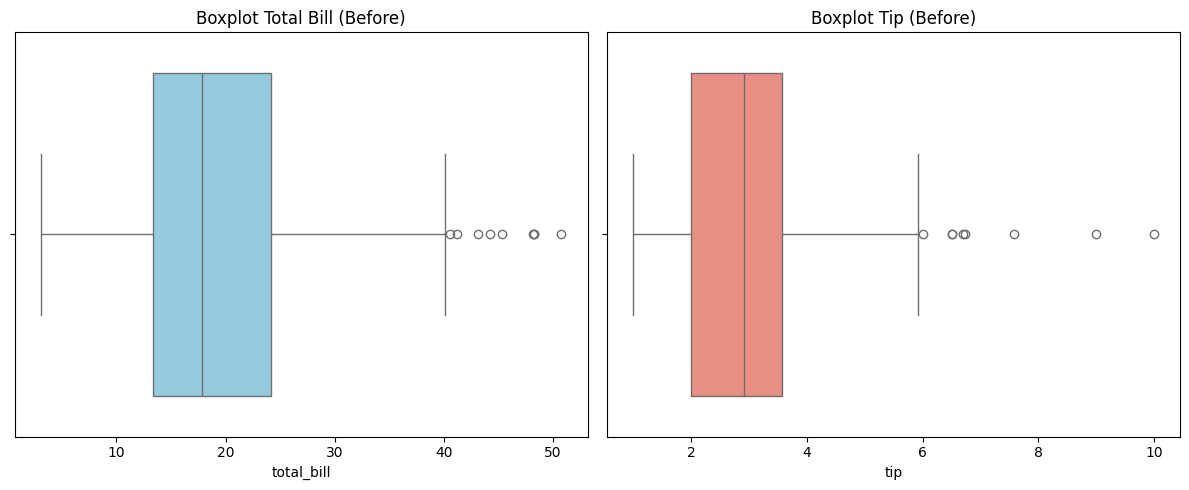

--- Outliers telah ditangani dengan metode Capping ---


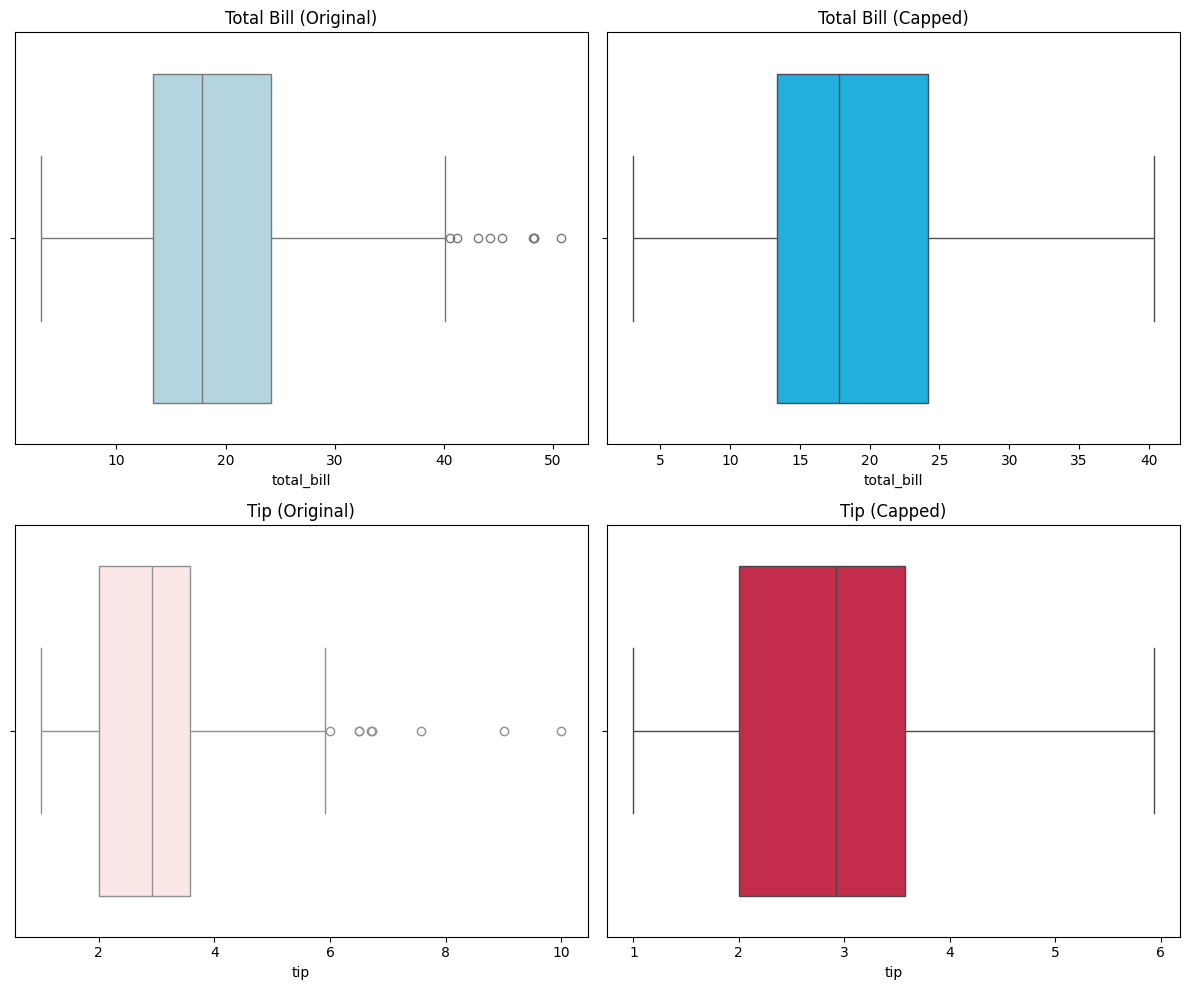

In [ ]:
#TUGAS 2

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_final['total_bill'], color='skyblue')
plt.title('Boxplot Total Bill (Before)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_final['tip'], color='salmon')
plt.title('Boxplot Tip (Before)')

plt.tight_layout()
plt.show()

df_capped = df_final.copy()
cols_to_cap = ['total_bill', 'tip']

for col in cols_to_cap:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("--- Outliers telah ditangani dengan metode Capping ---")

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x=df_final['total_bill'], color='lightblue')
plt.title('Total Bill (Original)')

plt.subplot(2, 2, 2)
sns.boxplot(x=df_capped['total_bill'], color='deepskyblue')
plt.title('Total Bill (Capped)')

plt.subplot(2, 2, 3)
sns.boxplot(x=df_final['tip'], color='mistyrose')
plt.title('Tip (Original)')

plt.subplot(2, 2, 4)
sns.boxplot(x=df_capped['tip'], color='crimson')
plt.title('Tip (Capped)')

plt.tight_layout()
plt.show()

C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_16260\1404107767.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='day', palette='viridis', order=['Thur', 'Fri', 'Sat', 'Sun'])


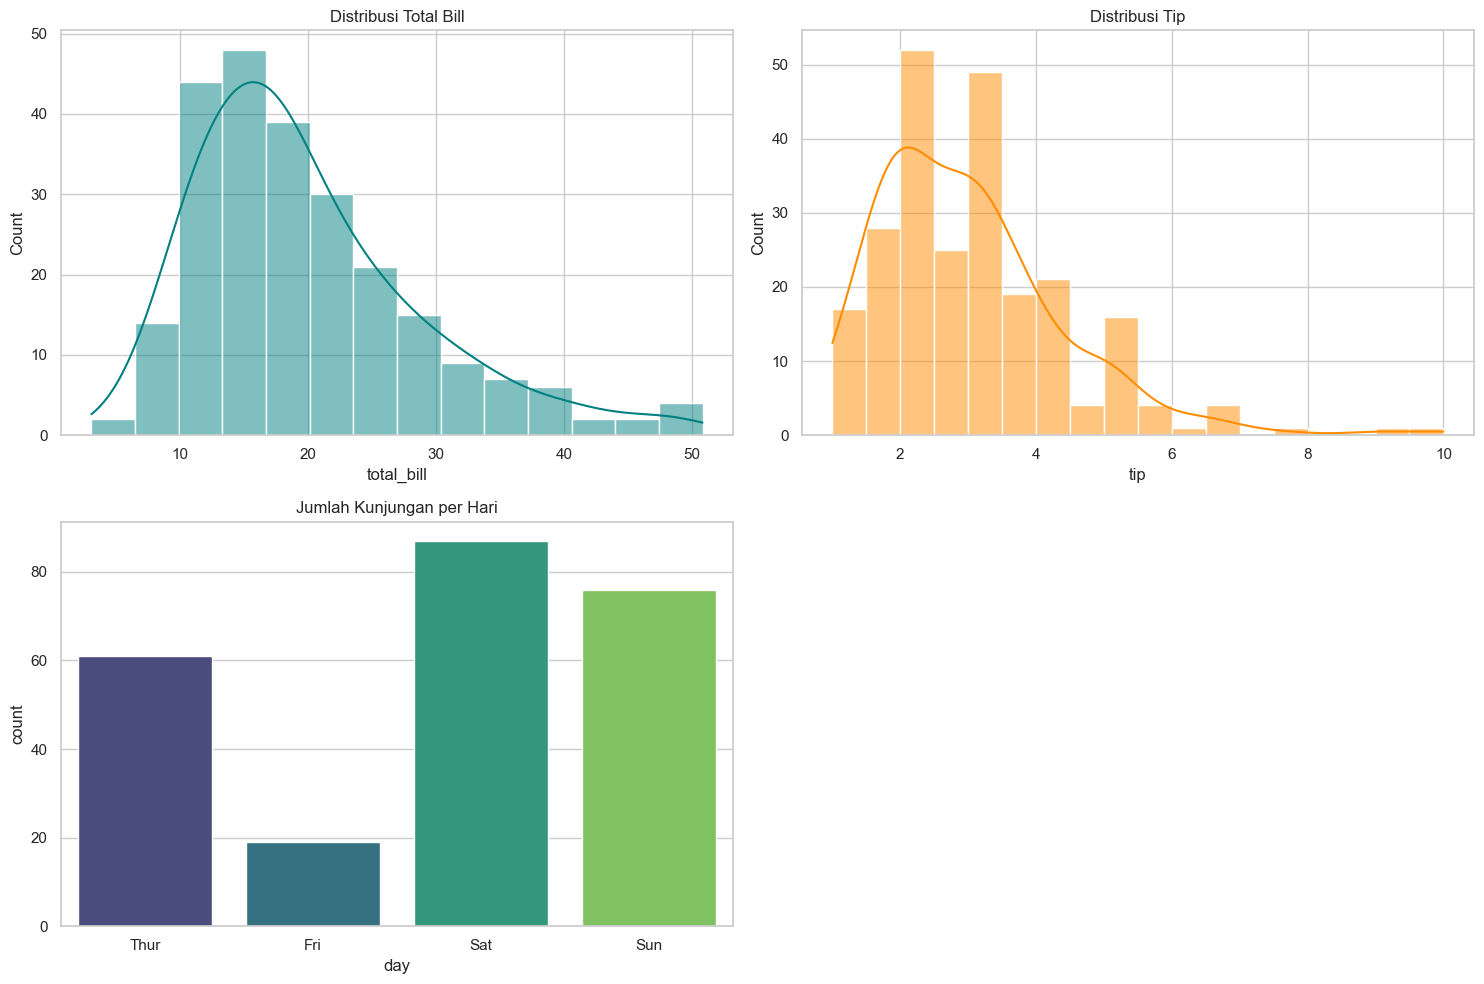

--- 3. Crosstab: Hubungan Perokok dan Hari ---
smoker  Yes  No
day            
Thur     16  45
Fri      15   4
Sat      42  45
Sun      19  57


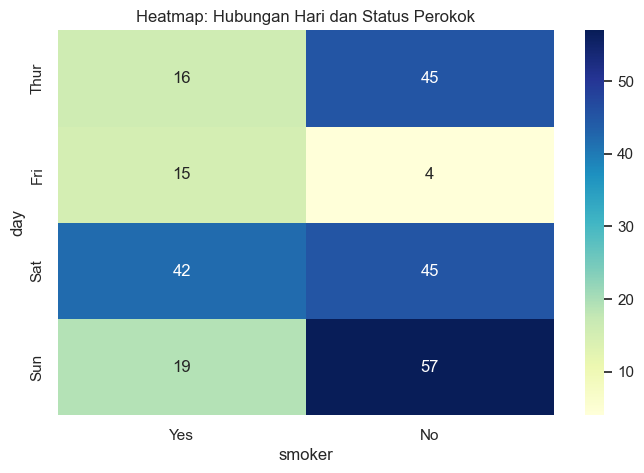

In [ ]:
#TUGAS 3
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_final['total_bill'], kde=True, color='teal')===
plt.title('Distribusi Total Bill')

plt.subplot(2, 2, 2)
sns.histplot(df_final['tip'], kde=True, color='darkorange')
plt.title('Distribusi Tip')

plt.subplot(2, 2, 3)
sns.countplot(data=df_final, x='day', palette='viridis', order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Jumlah Kunjungan per Hari')

plt.tight_layout()
plt.show()

print("--- 3. Crosstab: Hubungan Perokok dan Hari ---")
cross_tab = pd.crosstab(df_final['day'], df_final['smoker'])
print(cross_tab)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap: Hubungan Hari dan Status Perokok')
plt.show()